In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import liana as li
import scanpy as sc
import numpy as np
import pandas as pd

from plotnine import theme, element_text, element_blank, scale_x_discrete, scale_color_gradientn

In [ ]:
sc.set_figure_params(frameon=False)
sc.settings.verbosity = 2

In [5]:
# set working directory
project_dir = os.path.join(os.path.expanduser("~"), "BreastCancerG0arrest/")
working_dir = project_dir + "00_revisions/"
os.chdir(working_dir)

# figure directory
figure_dir = working_dir + "figures/"
# data directory
data_dir = working_dir + "data/"

In [6]:
# Read in
adata = sc.read_h5ad(data_dir + "xenium_aligned_ductal_invasive_with_cycling_states_and_hotspots.h5ad")

In [7]:
adata.X = adata.layers["counts"].copy()
sc.pp.filter_genes(adata, min_cells=1)
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)

normalizing counts per cell
    finished (0:00:00)


In [ ]:
adata.obs["cell_type"] = adata.obs["celltype_major"].astype(str).copy()
adata.obs.loc[pd.notna(adata.obs["G0_arrested_hot"]), "cell_type"] = "G0_arrested_hot"
adata.obs.loc[pd.notna(adata.obs["CXCL10_macrophage_score_hot"]), "cell_type"] = "CXCL10_macrophage_score_hot"

In [9]:
li.mt.rank_aggregate(
    adata,
    groupby="cell_type",
    resource_name="consensus",
    aggregate_method="rra",
    expr_prop=0.1,
    use_raw=False,
    de_method="wilcoxon",
    return_all_lrs=False,
    verbose=True,
    n_jobs=32,
)

Using resource `consensus`.
Using `.X`!
Converting `cell_type` to categorical!
0.94 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 139320 samples and 31 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:06<00:00, 154.10it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [10]:
sources = ["CXCL10_macrophage_score_hot", "G0_arrested_hot"]
targets = ["CXCL10_macrophage_score_hot", "G0_arrested_hot"]

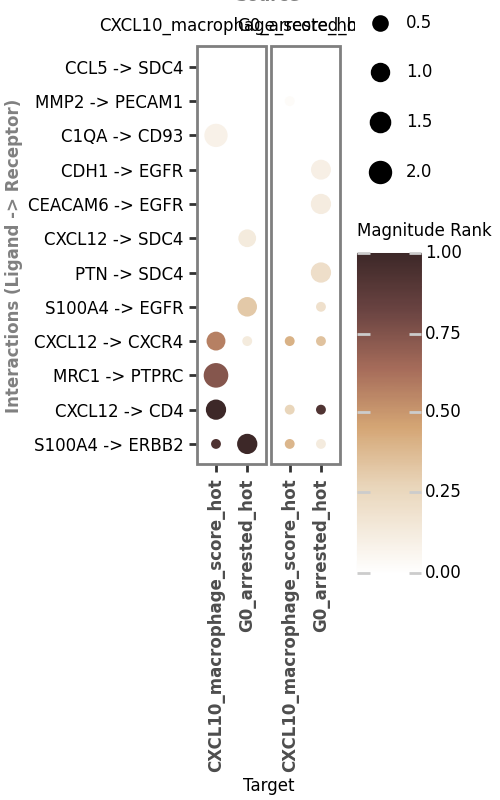

In [11]:
figure = (
    li.pl.dotplot(
        adata=adata,
        colour="magnitude_rank",
        size="specificity_rank",
        inverse_colour=True,
        inverse_size=True,
        source_labels=sources,
        target_labels=targets,
        # filter_fun=lambda x: x["specificity_rank"] <= 0.1 and x["magnitude_rank"] > 0.1,
        orderby="magnitude_rank",
        orderby_ascending=True,
        top_n=30,
        figure_size=(2.5, 4),
        size_range=(1, 4),
    )
    + theme(text=element_text(size=6), panel_grid=element_blank(), strip_background=element_blank())
    + scale_x_discrete(limits=["CXCL10_macrophage_score_hot", "G0_arrested_hot"])
    + scale_color_gradientn(
        colors=[
            "#ffffff",
            "#e8d4b8",  # beige
            "#d4a574",  # tan
            "#a66c5a",  # terracotta
            "#6b4442",  # muted maroon
            "#3d2828",
        ],  # dark brown
        values=[0, 0.28, 0.46, 0.64, 0.82, 1],
        limits=(0, 1),
        name="Magnitude Rank",
    )
)

figure.save(figure_dir + "xenium_liana_dotplot.pdf")
figure